# Pandas and Matplotlib Visualization

### Read in TSwift_Lyrics_Polarity.csv

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
lyrics_df = pd.read_csv("TSwift_Lyrics_Polarity.csv")

In [5]:
lyrics_df
#Polarity is positive or negative lyrics song 

,Unnamed: 0,X,album,song_file,release_date,lyrics,polarity,subjectivity
0,0,1,Taylor Swift,APerfectlyGoodHeart.txt,10/24/2006,Why would you wanna break A perfectly good hea...,0.512500,0.520833
1,1,2,Taylor Swift,APlaceInThisWorld.txt,10/24/2006,"I don't know what I want, so don't ask me 'Cau...",0.216111,0.700556
2,2,3,Taylor Swift,ColdasYou.txt,10/24/2006,You have a way of coming easily to me And when...,0.247917,0.764167
3,3,4,Taylor Swift,ImOnlyMeWhenImWithYou.txt,10/24/2006,Friday night beneath the stars In a field behi...,0.003208,0.658181
4,4,5,Taylor Swift,Invisible.txt,10/24/2006,She can't see the way your eyes Light up when ...,0.288435,0.752721
...,...,...,...,...,...,...,...,...
167,167,9,Midnights,Question____.txt,10/21/2022,"I remember Good girl, sad boy Big city, wrong ...",0.164732,0.364782
168,168,10,Midnights,SnowOnTheBeach.txt,10/21/2022,"One night, a few moons ago I saw flecks of wha...",-0.130314,0.495169
169,169,11,Midnights,SweetNothing.txt,10/21/2022,I spy with my little tired eye Tiny as a firef...,0.103902,0.403836
170,170,12,Midnights,VigilanteShit.txt,10/21/2022,Draw the cat eye sharp enough to kill a man Yo...,-0.196914,0.663228


# Find max and min polarity score for the songs.

In [9]:
#You can use .sortvalues() and then type the answer in a markdown cell below.
lyrics_df.sort_values("polarity", ascending=False) #Sort lyrics_df by the polarity column in descending order

,Unnamed: 0,X,album,song_file,release_date,lyrics,polarity,subjectivity
0,0,1,Taylor Swift,APerfectlyGoodHeart.txt,10/24/2006,Why would you wanna break A perfectly good hea...,0.512500,0.520833
160,160,2,Midnights,Bejeweled.txt,10/21/2022,"Baby love, I think I've been a little too kind...",0.487417,0.582444
171,171,13,Midnights,YoureOnYourOwn_Kid.txt,10/21/2022,"Summer went away, still, the yearning stays I ...",0.467647,0.723529
9,9,10,Taylor Swift,StayBeautiful.txt,10/24/2006,"Corey's eyes are like a jungle He smiles, it's...",0.437351,0.672917
89,89,13,1989,WelcometoNewYork.txt,10/27/2014,"Walking through a crowd, the village is aglow ...",0.420428,0.657897
...,...,...,...,...,...,...,...,...
143,143,16,Folklore,thisismetrying.txt,7/24/2020,I've been having a hard time adjusting I had t...,-0.210370,0.434259
79,79,3,1989,BadBlood.txt,10/27/2014,"'Cause baby, now we've got bad blood You know ...",-0.259043,0.624881
136,136,9,Folklore,madwoman.txt,7/24/2020,What did you think I'd say to that? Does a sco...,-0.299194,0.774194
164,164,6,Midnights,Maroon.txt,10/21/2022,When the morning came We were cleaning incense...,-0.371212,0.729293


# Let's groupby album and graph it out in a bar chart.

In [10]:
albums = lyrics_df.groupby('album').agg({'polarity':'mean'}) 
albums

,polarity
album,
1989,0.033333
Evermore,0.134908
Fearless,0.089626
Folklore,0.033462
Lover,0.075428
Midnights,0.100068
Red,0.100303
Reputation,0.067020
Speak Now,0.099885


In [2]:
import matplotlib.pyplot as plt

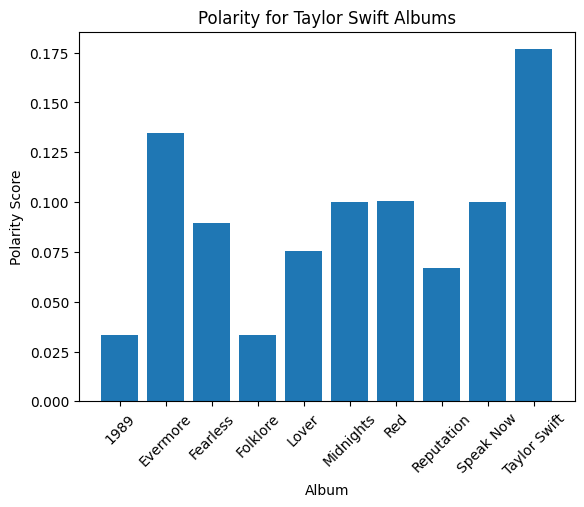

In [11]:
plt.bar(albums.index, albums['polarity'])
plt.title('Polarity for Taylor Swift Albums')
plt.xlabel('Album')
plt.ylabel('Polarity Score')
plt.xticks(rotation=45, fontsize=10)
plt.show()

# Let's groupby year and use a line graph to see if there are any changes over time

In [16]:
lyrics_df['release_date'] = pd.to_datetime(lyrics_df['release_date']) #Convert this column to a date/time object

In [17]:
years = lyrics_df.groupby(lyrics_df['release_date'].dt.year).agg({'polarity':'mean'}) #Group by the lyrics_df column[release date] year.
#Aggregate the data based off polarity mean
years

,polarity
release_date,
2006,0.176655
2008,0.089626
2010,0.099885
2012,0.100303
2014,0.033333
2017,0.067020
2019,0.075428
2020,0.082549
2022,0.100068


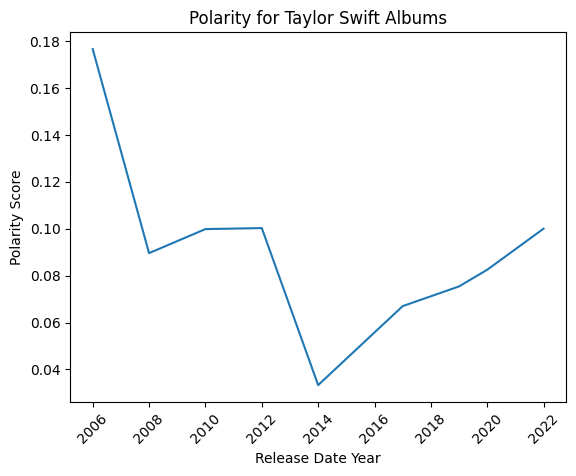

In [19]:
plt.plot(years.index, years['polarity']) #.plot defaults to a line chart
plt.title('Polarity for Taylor Swift Albums')
plt.xlabel('Release Date Year')
plt.ylabel('Polarity Score')
plt.xticks(rotation=45, fontsize=10)
plt.show()

# Now plot the album graph and the year graph on top of each other using plt.subplots()

Text(0, 0.5, 'Polarity Score')

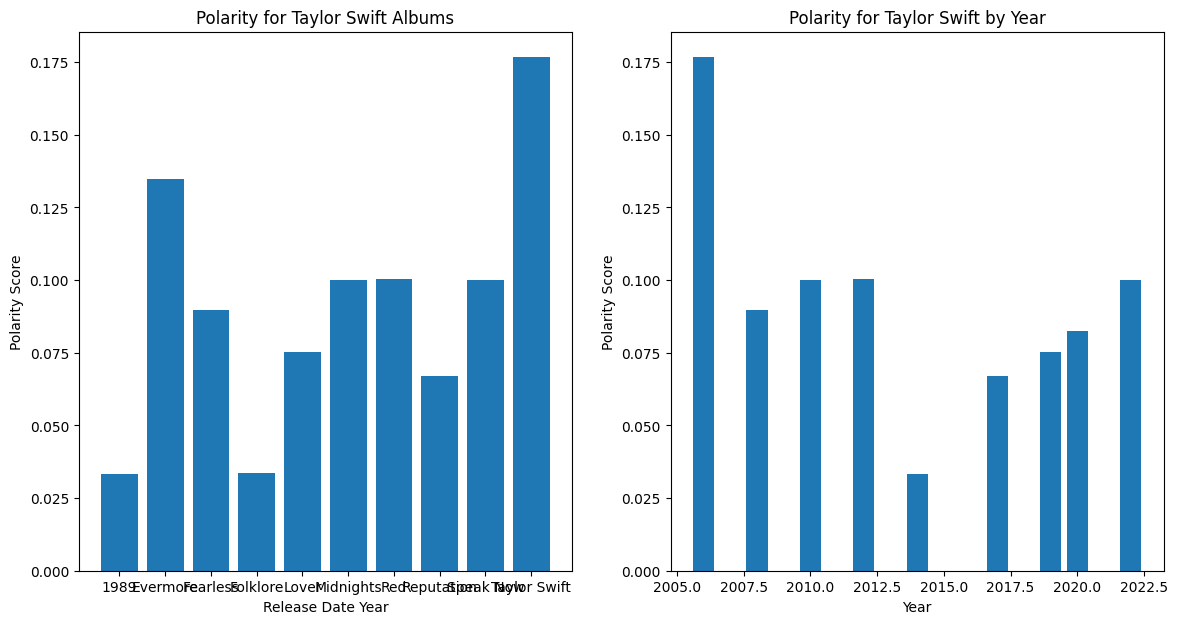

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14,7)) #plt.subplots(number rows of graphs, number of columns of graphs, figsize=(14,7))
#Creating a figure(fig), Create axes within figure(axs)

ax1 = axs[0] #First graph
ax2 = axs[1] #Second graph

ax1.bar(albums.index, albums['polarity'])
ax1.set_title('Polarity for Taylor Swift Albums')
ax1.set_xlabel('Release Date Year')
ax1.set_ylabel('Polarity Score')

ax2.bar(years.index, years['polarity'])
ax2.set_title('Polarity for Taylor Swift by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Polarity Score')

# Now try with using Microsoft Co-Pilot to see if it will achieve similar results (optional)

# Machine Learning (Module 7)

# Regression Practice

**Note:** This set of exercises are about regression, not about classification you learned in the lecture. The overall process for regression, however, should be the same as that for classification, except that you want to predict a number, not a class label. 

We'll be using the MPG dataset in seaborn. The MPG dataset contains information about miles per gallon for different car models and their attributes. It includes features such as miles per gallon, number of cylinders in the engine, engine displacement, engine horsepower, vehicle weight, acceleration, model year, origin of the car, and car model name.

**Features and Characteristics**

- mpg: Miles per gallon (numerical)
- cylinders: Number of cylinders in the engine (numerical)
- displacement: Engine displacement in cubic inches (numerical)
- horsepower: Engine horsepower (numerical)
- weight: Vehicle weight in pounds (numerical)
- acceleration: Acceleration in seconds from 0 to 60 mph (numerical)
- model_year: Model year (categorical)
- origin: Origin of the car (categorical)
- name: Car model name (string)

In [26]:
pip install --upgrade seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from seaborn import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

dfm = sns.load_dataset("mpg")
#dfm = pd.read_csv("mpg.csv")


In [3]:
dfm

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [6]:
dfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    str    
 9   name          398 non-null    str    
dtypes: float64(4), int64(4), str(2)
memory usage: 31.2 KB


In [7]:
dfm.dropna(inplace=True) #Eliminates(drops) missing values from dataset

Assume that we can use features `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year` to predict the `mpg`.

In [8]:
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]
target = "mpg"

1\. You need two variables, `X` as the features set and `y` as the target set. Select the feature columns in `dfm` and save the resulting dataframe in the variable `X`. Likewise, select the target column in `dfm` and save it in the variable `y`.

In [15]:
# Your answer here
X = dfm[features]
y= dfm[target]

In [16]:
X

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6
394,4,97.0,52.0,2130,24.6
395,4,135.0,84.0,2295,11.6
396,4,120.0,79.0,2625,18.6


2\. Split `X` and `y` into 80% of training sets `X_train` and `y_train` and 20% of test sets `X_test` and `y_test`. Set `random_state` to 0.

In [17]:
# Your answer here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

You can initialize a linear regression model object `lr` as follows:

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

6\. Fit the linear regression model `lr` using the two training sets.

In [19]:
# Your answer here
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


7\. Get the training score and test score, respectively. 

In [20]:
# Your answer here
lr.score(X_train, y_train)

0.7218154836440223

In [21]:
lr.score(X_test, y_test)

0.6472300190499063

# Classification

In [22]:
# Load mortgage data
mortgage = pd.read_csv("mortgage.txt", sep="|", na_values=["NA", "-", ""])

In [23]:
mortgage

,CreditScore,HomeAge,YearsEmployed,CreditCardDebt,Year,Default
0,752,24,3.0,8930.0,2009.0,1
1,715,9,8.0,6403.0,2009.0,0
2,635,16,5.0,7561.0,2008.0,0
3,744,20,6.0,8628.0,2008.0,1
4,756,26,8.0,6083.0,2008.0,0
...,...,...,...,...,...,...
1290,786,21,3.0,5544.0,2007.0,0
1291,720,20,6.0,9676.0,2009.0,1
1292,676,17,4.0,8555.0,2008.0,1
1293,620,12,5.0,5370.0,2007.0,0


In [6]:
# Load mortgage data
mortgage = pd.read_csv("mortgage.txt", sep="|", na_values=["NA", "-", ""])
#Drop na values:
mortgage.dropna(inplace=True)

display(mortgage)
dummies = pd.get_dummies(mortgage['Year'])


# Concatenate the original DataFrame with the new dummy DataFrame
mortgage = pd.concat([mortgage, dummies], axis=1)
mortgage.drop("Year", axis=1, inplace=True)
display(mortgage)

,CreditScore,HomeAge,YearsEmployed,CreditCardDebt,Year,Default
0,752,24,3.0,8930.0,2009.0,1
1,715,9,8.0,6403.0,2009.0,0
2,635,16,5.0,7561.0,2008.0,0
3,744,20,6.0,8628.0,2008.0,1
4,756,26,8.0,6083.0,2008.0,0
...,...,...,...,...,...,...
1290,786,21,3.0,5544.0,2007.0,0
1291,720,20,6.0,9676.0,2009.0,1
1292,676,17,4.0,8555.0,2008.0,1
1293,620,12,5.0,5370.0,2007.0,0


,CreditScore,HomeAge,YearsEmployed,CreditCardDebt,Default,2007.0,2008.0,2009.0
0,752,24,3.0,8930.0,1,False,False,True
1,715,9,8.0,6403.0,0,False,False,True
2,635,16,5.0,7561.0,0,False,True,False
3,744,20,6.0,8628.0,1,False,True,False
4,756,26,8.0,6083.0,0,False,True,False
...,...,...,...,...,...,...,...,...
1290,786,21,3.0,5544.0,0,True,False,False
1291,720,20,6.0,9676.0,1,False,False,True
1292,676,17,4.0,8555.0,1,False,True,False
1293,620,12,5.0,5370.0,0,True,False,False


# Get the accuracy score for logistic regression (next week we'll compare to KNN and decision trees)

In [7]:
# Classifier Template
# Import the module (already done above)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

X = mortgage.drop("Default", axis=1).values
y = mortgage["Default"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
log = LogisticRegression()

# Fit the classifier to the training data
log.fit(X_train, y_train)

#Get the predictions
#y_pred = model.predict(X_test)

# Print the accuracy
print(log.score(X_test, y_test))

0.9147286821705426


/home/jrgoebel/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
